# Importing Libraries

In [1]:
# Importing Libraries
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import scipy

In [2]:
# Define the file path
path = r'C:\Users\rbhte\OneDrive\monami\data_immersion\Achievement 6'

# Correctly reading the pickle file
df_happy = pd.read_pickle(os.path.join(path, 'Data', 'Prepared Data', 'df_happiness.pkl'))

# Check the columns
print(df_happy.columns)

Index(['Country name', 'year', 'Life Ladder', 'Log GDP per capita',
       'Social support', 'Healthy life expectancy at birth',
       'Freedom to make life choices', 'Generosity',
       'Perceptions of corruption', 'Positive affect', 'Negative affect',
       'Happiness Score', 'z_score'],
      dtype='object')


In [3]:
df_happy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2317 entries, 0 to 2362
Data columns (total 13 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Country name                      2317 non-null   object 
 1   year                              2317 non-null   int64  
 2   Life Ladder                       2317 non-null   float64
 3   Log GDP per capita                2317 non-null   float64
 4   Social support                    2317 non-null   float64
 5   Healthy life expectancy at birth  2317 non-null   float64
 6   Freedom to make life choices      2317 non-null   float64
 7   Generosity                        2317 non-null   float64
 8   Perceptions of corruption         2317 non-null   float64
 9   Positive affect                   2317 non-null   float64
 10  Negative affect                   2317 non-null   float64
 11  Happiness Score                   2317 non-null   float64
 12  z_score    

# Create a correlation matrix heatmap

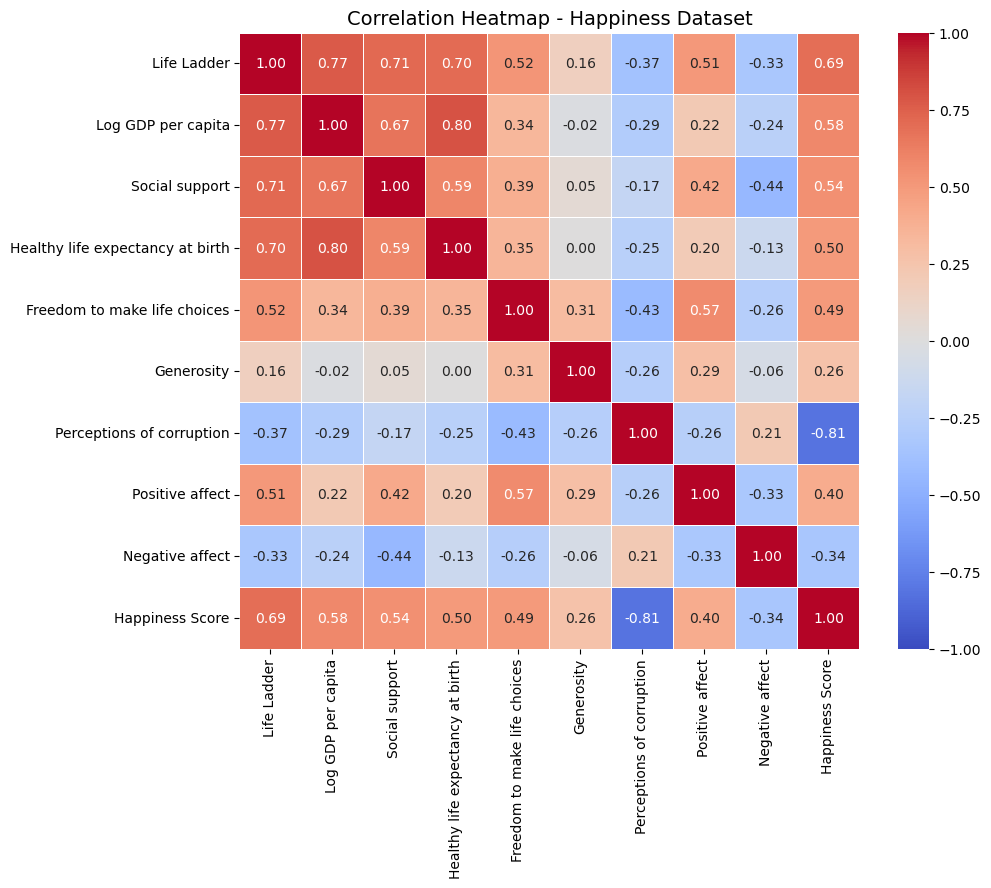

Heatmap saved successfully at: C:\Users\rbhte\OneDrive\monami\data_immersion\Achievement 6\Visualisations\correlation_heatmap.png


In [4]:
# Drop non-numeric columns before correlation
df_numeric = df_happy.drop(columns=['Country name', 'year', 'z_score'])

# Compute the correlation matrix
corr_matrix = df_numeric.corr()

# Set up the figure
plt.figure(figsize=(10, 8))

# Create a heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)

# Title
plt.title("Correlation Heatmap - Happiness Dataset", fontsize=14)

# Define the full path for saving
heatmap_path = os.path.join(path, 'Visualisations', 'correlation_heatmap.png')

# Save the heatmap
plt.savefig(heatmap_path, dpi=300, bbox_inches='tight')

# Show the plot
plt.show()

print(f"Heatmap saved successfully at: {heatmap_path}")

### Interpretation of the Correlation Heatmap

#1. Strong Positive Correlations (Closer to +1): 
#   Life ladder and log gdp per capita (0.77): higher income is strongly linked to well-being.
#   Life ladder and social support (0.71): strong social connections improve life satisfaction.
#   Life ladder and healthy life expectancy (0.70): longer, healthier lives contribute to happiness.
#   Log gdp per capita and healthy life expectancy (0.80): wealthier countries tend to have better healthcare.
#2. Moderate Positive Correlations (0.3 to 0.7):
#   Happiness Score & Life Ladder (0.69): Life satisfaction strongly influences happiness.  
#   Social support and happiness score (0.54): social connections boost happiness.
#   Freedom to make life choices and positive affect (0.57): more freedom leads to positive emotions.

#3. Weak or No Correlation (Close to 0):
#   Generosity & Other Variables (Mostly close to 0): Generosity has little impact on life satisfaction and GDP.  

#4. Strong Negative Correlations (Closer to -1):  
#   Happiness Score & Perceptions of Corruption (-0.81): High corruption lowers happiness significantly.  
#   Life Ladder & Perceptions of Corruption (-0.37): Corruption negatively affects well-being.  
#   Social Support & Negative Affect (-0.44): Lack of social support is linked to negative emotions.  

# Create a scatterplot for the variables with the strongest correlations 

Scatterplot saved successfully at: C:\Users\rbhte\OneDrive\monami\data_immersion\Achievement 6\Visualisations\scatterplot_strongest_correlations.png


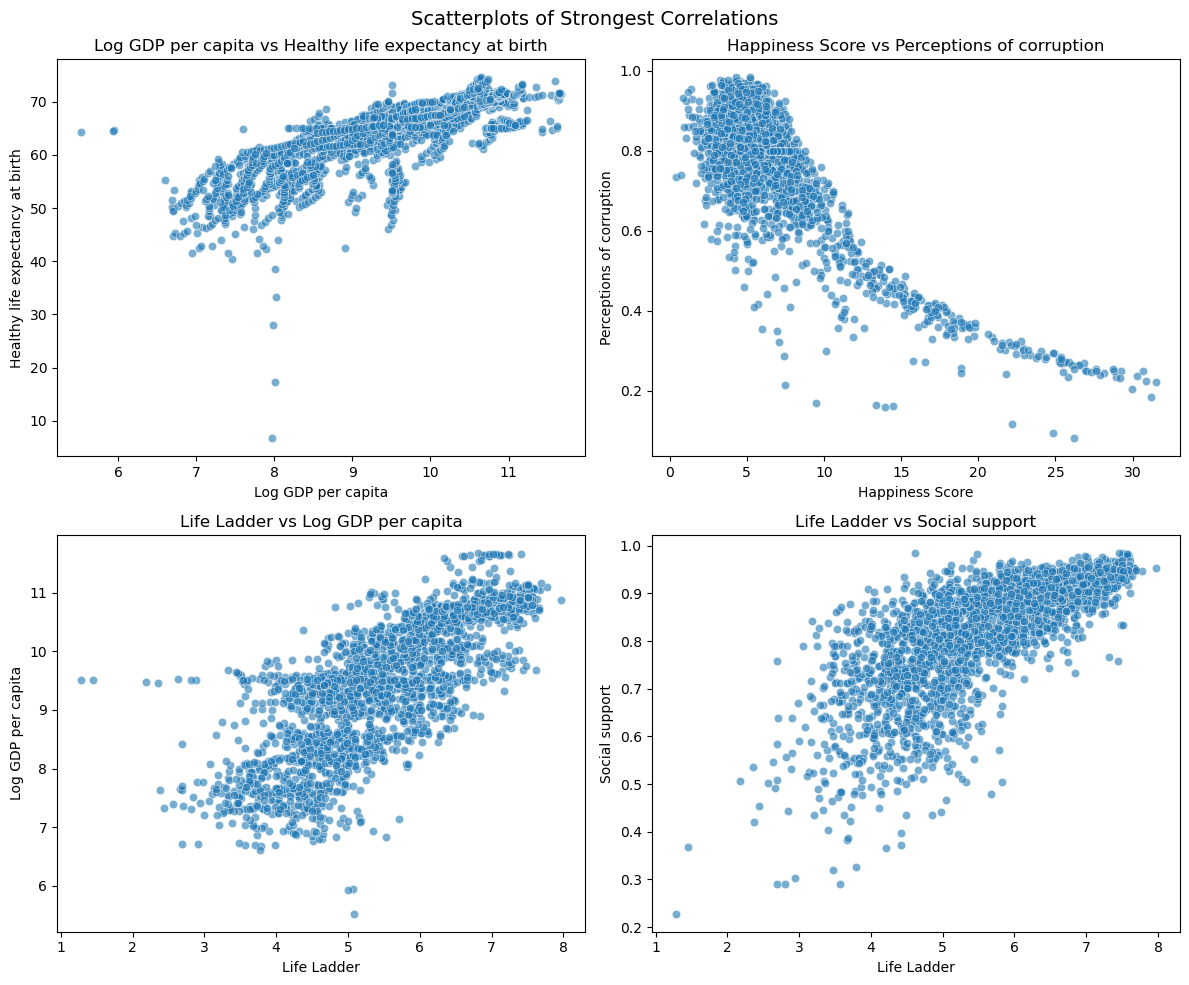

In [5]:
# Define the strongest correlations
strongest_pairs = [
    ('Log GDP per capita', 'Healthy life expectancy at birth'),
    ('Happiness Score', 'Perceptions of corruption'),
    ('Life Ladder', 'Log GDP per capita'),
    ('Life Ladder', 'Social support')
]

# Set the save location
save_location = os.path.join(path, 'Visualisations', 'scatterplot_strongest_correlations.png')

# Create scatterplots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle("Scatterplots of Strongest Correlations", fontsize=14)

for ax, (x, y) in zip(axes.flat, strongest_pairs):
    sns.scatterplot(data=df_happy, x=x, y=y, ax=ax, alpha=0.6)
    ax.set_title(f"{x} vs {y}")

plt.tight_layout()

# Save the figure
plt.savefig(save_location, dpi=300)
print(f"Scatterplot saved successfully at: {save_location}")

- **Log GDP per capita vs Healthy life expectancy at birth**: Strong positive correlation; as GDP increases, life expectancy rises.  
- **Happiness Score vs Perceptions of corruption**: Strong negative correlation; higher corruption perception is linked to lower happiness.  
- **Life Ladder vs Log GDP per capita**: Positive correlation; economic prosperity aligns with a higher quality of life.  
- **Life Ladder vs Social support**: Positive correlation; stronger social support is associated with a better quality of life.

# Create a pair plot of the entire data set

Pair plot saved successfully at: C:\Users\rbhte\OneDrive\monami\data_immersion\Achievement 6\Visualisations\pairplot_happiness.png


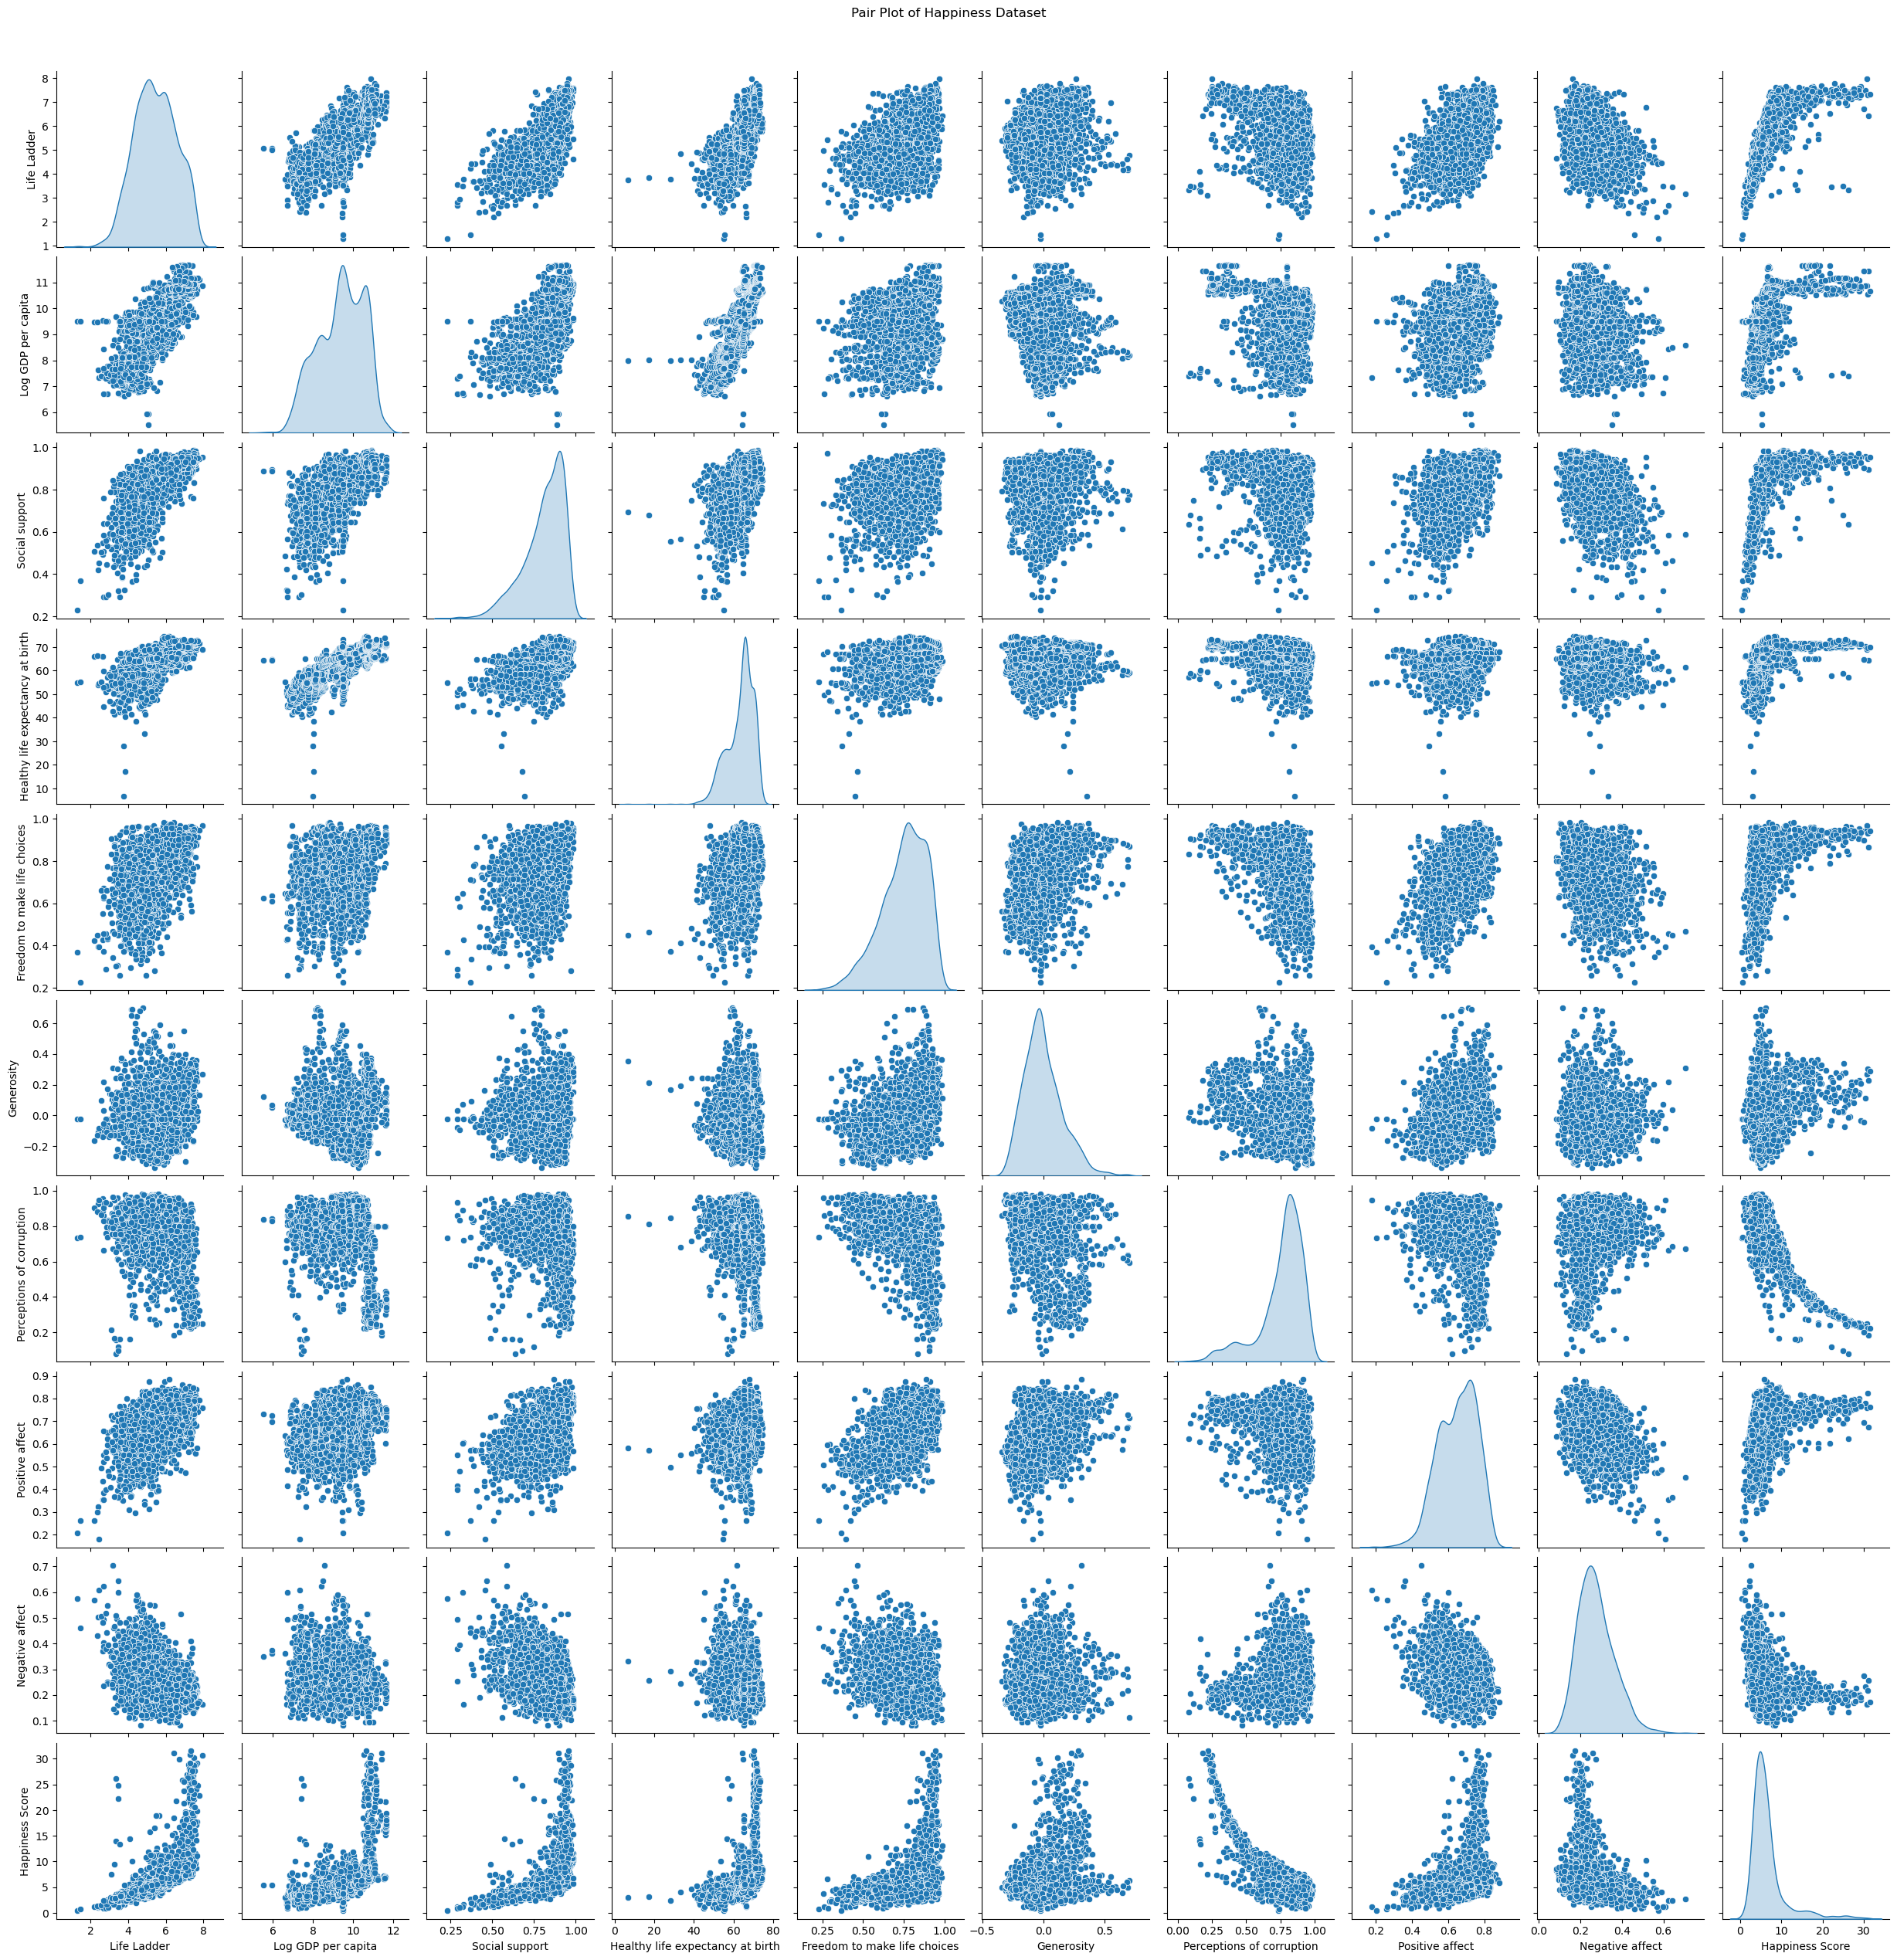

In [6]:
# Define the path to save the pair plot
pairplot_path = os.path.join(path, 'Visualisations', 'pairplot_happiness.png')

# Select only numerical columns for the pair plot
numerical_columns = ['Life Ladder', 'Log GDP per capita', 'Social support', 
                     'Healthy life expectancy at birth', 'Freedom to make life choices', 
                     'Generosity', 'Perceptions of corruption', 'Positive affect', 
                     'Negative affect', 'Happiness Score']

# Create the pair plot
sns.pairplot(df_happy[numerical_columns], diag_kind='kde')
plt.suptitle("Pair Plot of Happiness Dataset", y=1.02)

# Save the plot
plt.savefig(pairplot_path, dpi=300, bbox_inches='tight')
print(f"Pair plot saved successfully at: {pairplot_path}")

# Show the plot
plt.show()

# Combine a Scatterplot with a Histogram 

Pair plot saved successfully at: C:\Users\rbhte\OneDrive\monami\data_immersion\Achievement 6\Visualisations\pairplot_sh.png


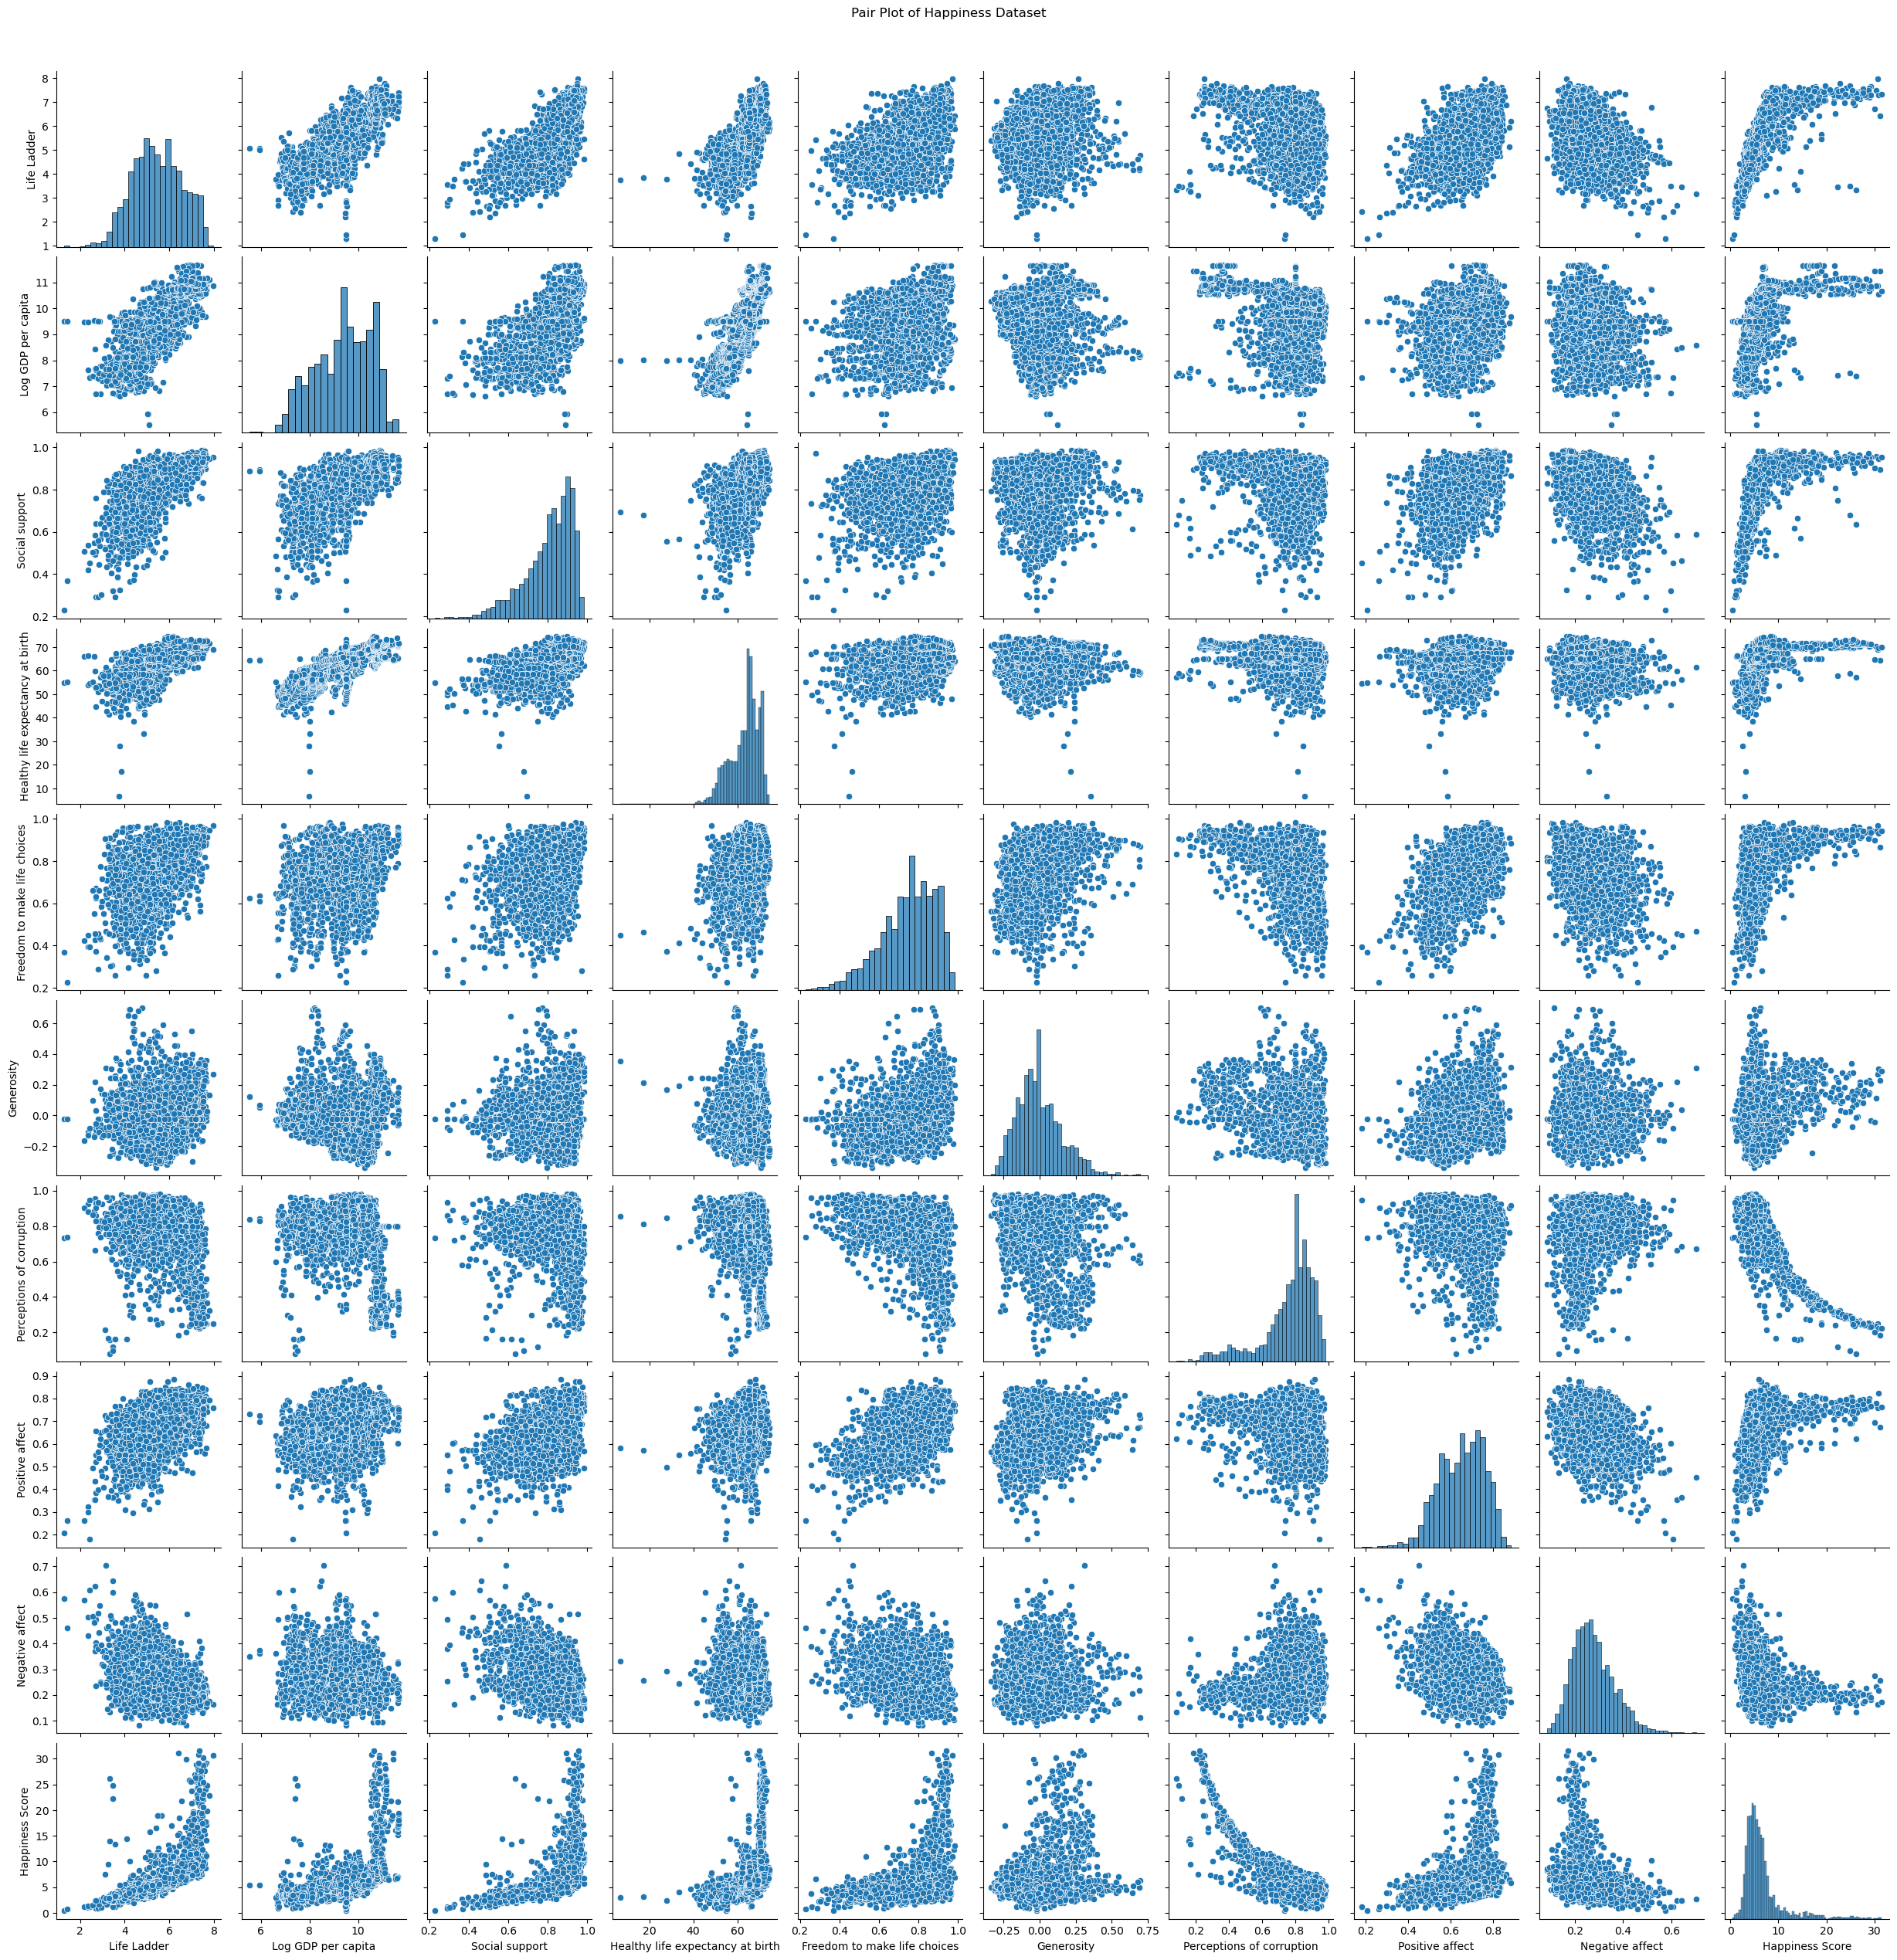

In [7]:
# Define the path to save the pair plot
path = r'C:\Users\rbhte\OneDrive\monami\data_immersion\Achievement 6'
pairplot_path_h = os.path.join(path, 'Visualisations', 'pairplot_sh.png')

# Select only numerical columns for the pair plot
numerical_columns = ['Life Ladder', 'Log GDP per capita', 'Social support', 
                     'Healthy life expectancy at birth', 'Freedom to make life choices', 
                     'Generosity', 'Perceptions of corruption', 'Positive affect', 
                     'Negative affect', 'Happiness Score']

# Create the pair plot with scatterplots and histograms
sns.pairplot(df_happy[numerical_columns], diag_kind='hist')  # Change diag_kind to 'kde' for density plots
plt.suptitle("Pair Plot of Happiness Dataset", y=1.02)

# Save the plot
plt.savefig(pairplot_path_h, dpi=300, bbox_inches='tight')
print(f"Pair plot saved successfully at: {pairplot_path_h}")

# Show the plot
plt.show()

### **Observations on Variable Distributions:**
1. **Most variables exhibit skewness**  
   - Log GDP per capita, Generosity, and Perceptions of Corruption show **right-skewed distributions**.
   - Negative affect and Positive affect have **a more uniform spread** but with some clusters.  

2. **Strong relationships observed**  
   - Life Ladder vs Log GDP per capita: **Positive correlation** suggests economic well-being affects happiness.  
   - Healthy life expectancy vs Log GDP per capita: **Strong positive relationship**, implying wealthier countries have better health.  
   - Happiness Score vs Perceptions of Corruption: **Negative correlation**, indicating higher corruption lowers happiness.  

### **Variables for Further Exploration:**
    Log GDP per capita & Healthy Life Expectancy
   - Very strong correlation. It would be interesting to see if this holds across income groups or specific regions.  

# Create a Categorical plot 

<Axes: xlabel='Happiness Score', ylabel='Count'>

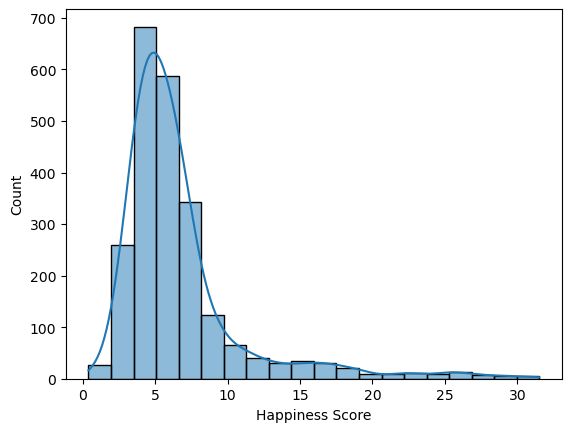

In [8]:
# Use a histogram to visualise the distribution of the 'Happiness Score' variable
sns.histplot(df_happy['Happiness Score'], bins = 20, kde = True)

# Summary of the 'Happiness Score' Column

In [9]:
# Get a summary of the 'Happiness Score' column
summary_stats = df_happy['Happiness Score'].describe()
print(summary_stats)

count    2317.000000
mean        6.693258
std         4.426704
min         0.398456
25%         4.223215
50%         5.505563
75%         7.195829
max        31.519302
Name: Happiness Score, dtype: float64


Categories:
"Low Happiness": Happiness Score < 4.5 (Below the 25th percentile)
"Medium Happiness": 4.5 <= Happiness Score < 7.5 (Between the 25th and 75th percentiles)
"High Happiness": Happiness Score >= 7.5 (Above the 75th percentile)

In [10]:
# Create a copy of the original dataframe
df_happy_copy = df_happy.copy()

# Create a new column 'Happiness Category' based on the Happiness Score
conditions = [
    (df_happy_copy['Happiness Score'] < 4.5),
    (df_happy_copy['Happiness Score'] >= 4.5) & (df_happy_copy['Happiness Score'] < 7.5),
    (df_happy_copy['Happiness Score'] >= 7.5)
]

# Labels for the categories
categories = ['Low Happiness', 'Medium Happiness', 'High Happiness']

# Apply the conditions to create the new column
df_happy_copy['Happiness Category'] = pd.cut(df_happy_copy['Happiness Score'], bins=[-float('inf'), 4.5, 7.5, float('inf')], labels=categories)

# Check the result
print(df_happy_copy[['Happiness Score', 'Happiness Category']].head())

   Happiness Score Happiness Category
0         1.904222      Low Happiness
1         2.858711      Low Happiness
2         3.627386      Low Happiness
3         2.731152      Low Happiness
4         2.539875      Low Happiness


# Create a Bar plot

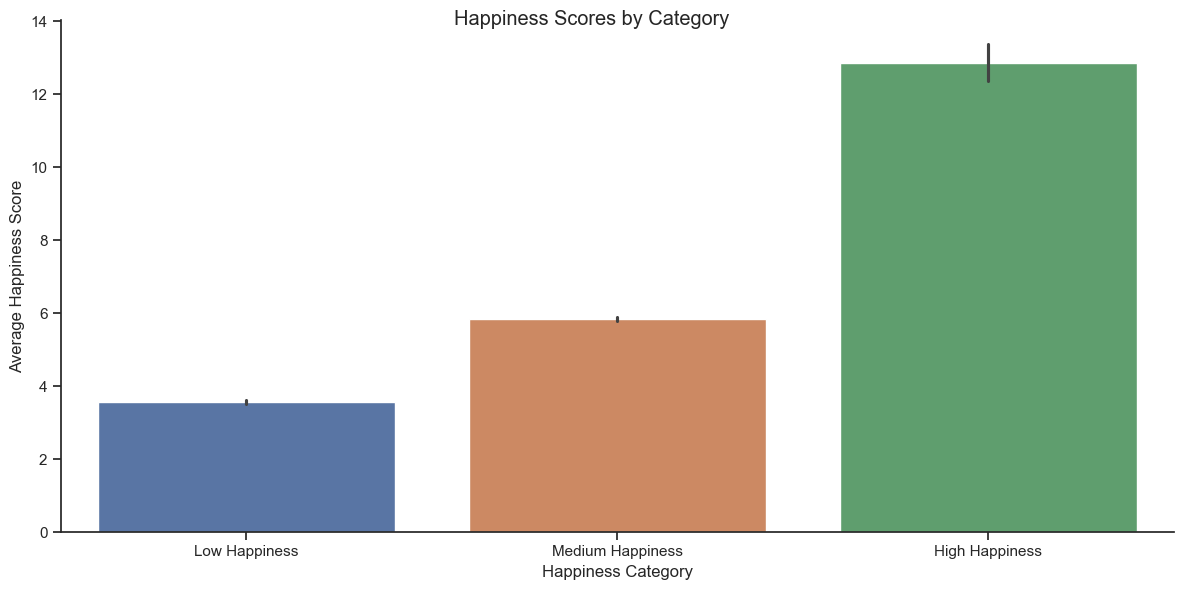

In [11]:
# Bar Plot (Best for Comparing Happiness Scores by Category)
sns.set(style="ticks")
f = sns.catplot(
    x="Happiness Category",
    y="Happiness Score",
    hue="Happiness Category",
    kind="bar",  # Categorical Bar Plot
    data=df_happy_copy,
    height=6,
    aspect=2
)

f.set_axis_labels("Happiness Category", "Average Happiness Score")
f.fig.suptitle("Happiness Scores by Category")
plt.show()

# Box Plot :  for Seeing Score Distributions

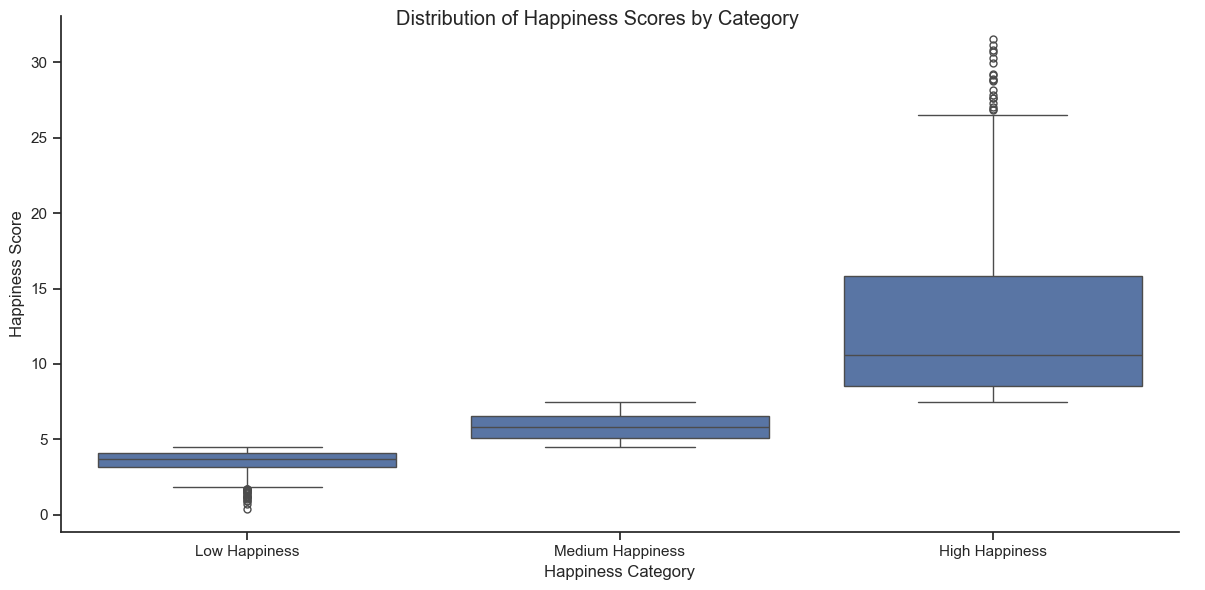

In [12]:
g = sns.catplot(
    x="Happiness Category",
    y="Happiness Score",
    kind="box",  # Categorical Box Plot
    data=df_happy_copy,
    height=6,
    aspect=2
)

g.set_axis_labels("Happiness Category", "Happiness Score")
g.fig.suptitle("Distribution of Happiness Scores by Category")
plt.show()

In [13]:
# Save the plot
boxplot_path = os.path.join(path, 'Visualisations', 'Happiness_scores_by_category.png')
g.savefig(boxplot_path)
print(f"Box plot saved successfully at: {boxplot_path}")

Box plot saved successfully at: C:\Users\rbhte\OneDrive\monami\data_immersion\Achievement 6\Visualisations\Happiness_scores_by_category.png


# Horizontal Bar Plot : for Ranking

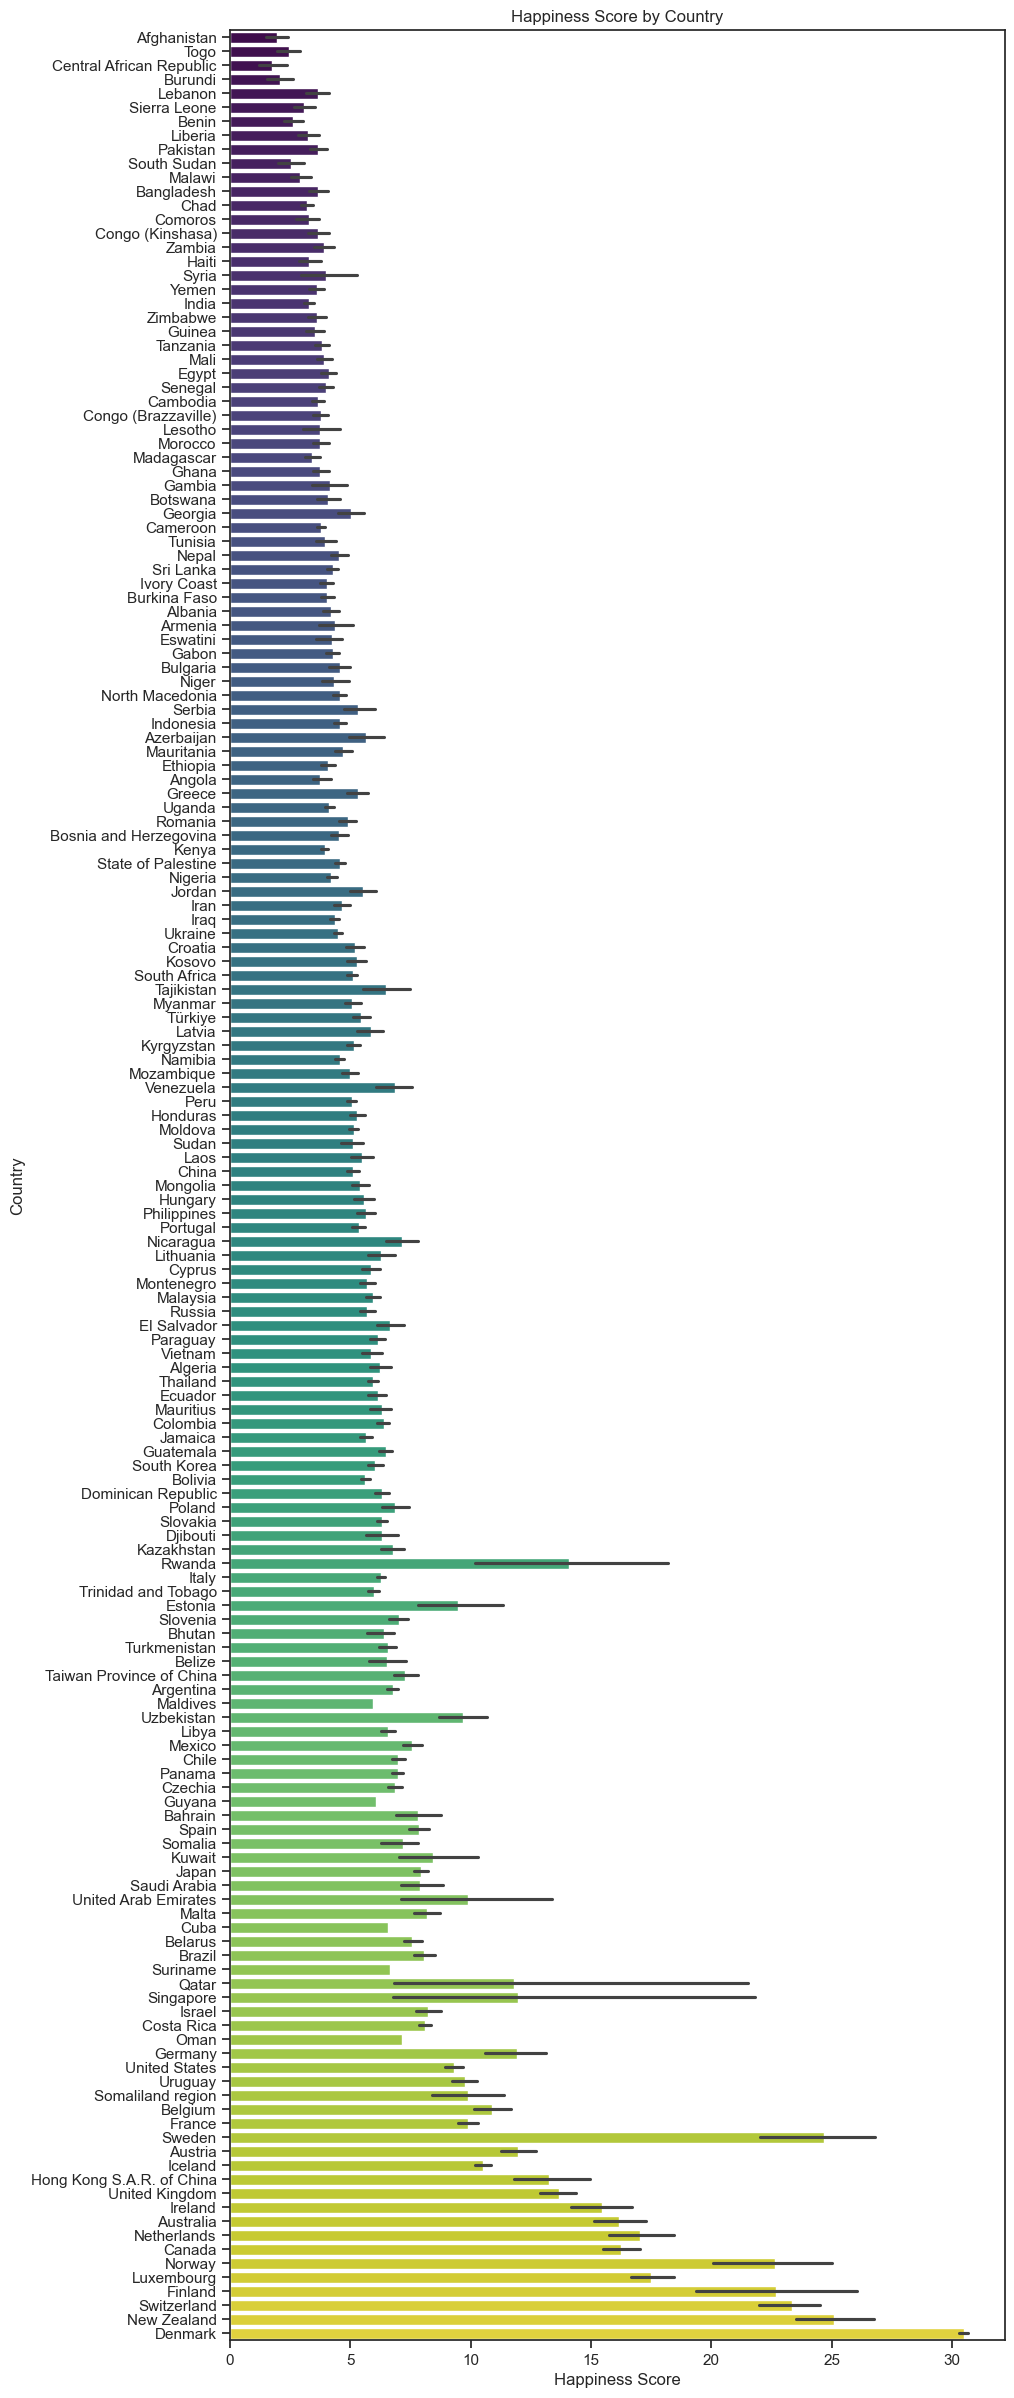

Bar plot saved successfully at: C:\Users\rbhte\OneDrive\monami\data_immersion\Achievement 6\Visualisations\Happiness_scores_by_country.png


In [15]:
# Sort the data by Happiness Score (Ascending)
df_happy_sorted_1 = df_happy_copy.sort_values(by="Happiness Score", ascending=True)

# Create figure
plt.figure(figsize=(10, 30))

# Create bar plot with explicit order
sns.barplot(
    x="Happiness Score", 
    y="Country name", 
    data=df_happy_sorted_1, 
    hue="Country name", 
    dodge=False, 
    legend=False, 
    palette="viridis",
    order=df_happy_sorted_1["Country name"]  # Ensure correct order
)

# Labels and title
plt.xlabel("Happiness Score")
plt.ylabel("Country")
plt.title("Happiness Score by Country")

# Define the path
barplot_path1 = os.path.join(path, 'Visualisations', 'Happiness_scores_by_country.png')

# Save the figure
plt.savefig(barplot_path1, bbox_inches="tight")
plt.show()

print(f"Bar plot saved successfully at: {barplot_path1}")

# Strip Plot (with Jitter to Prevent Overlap)

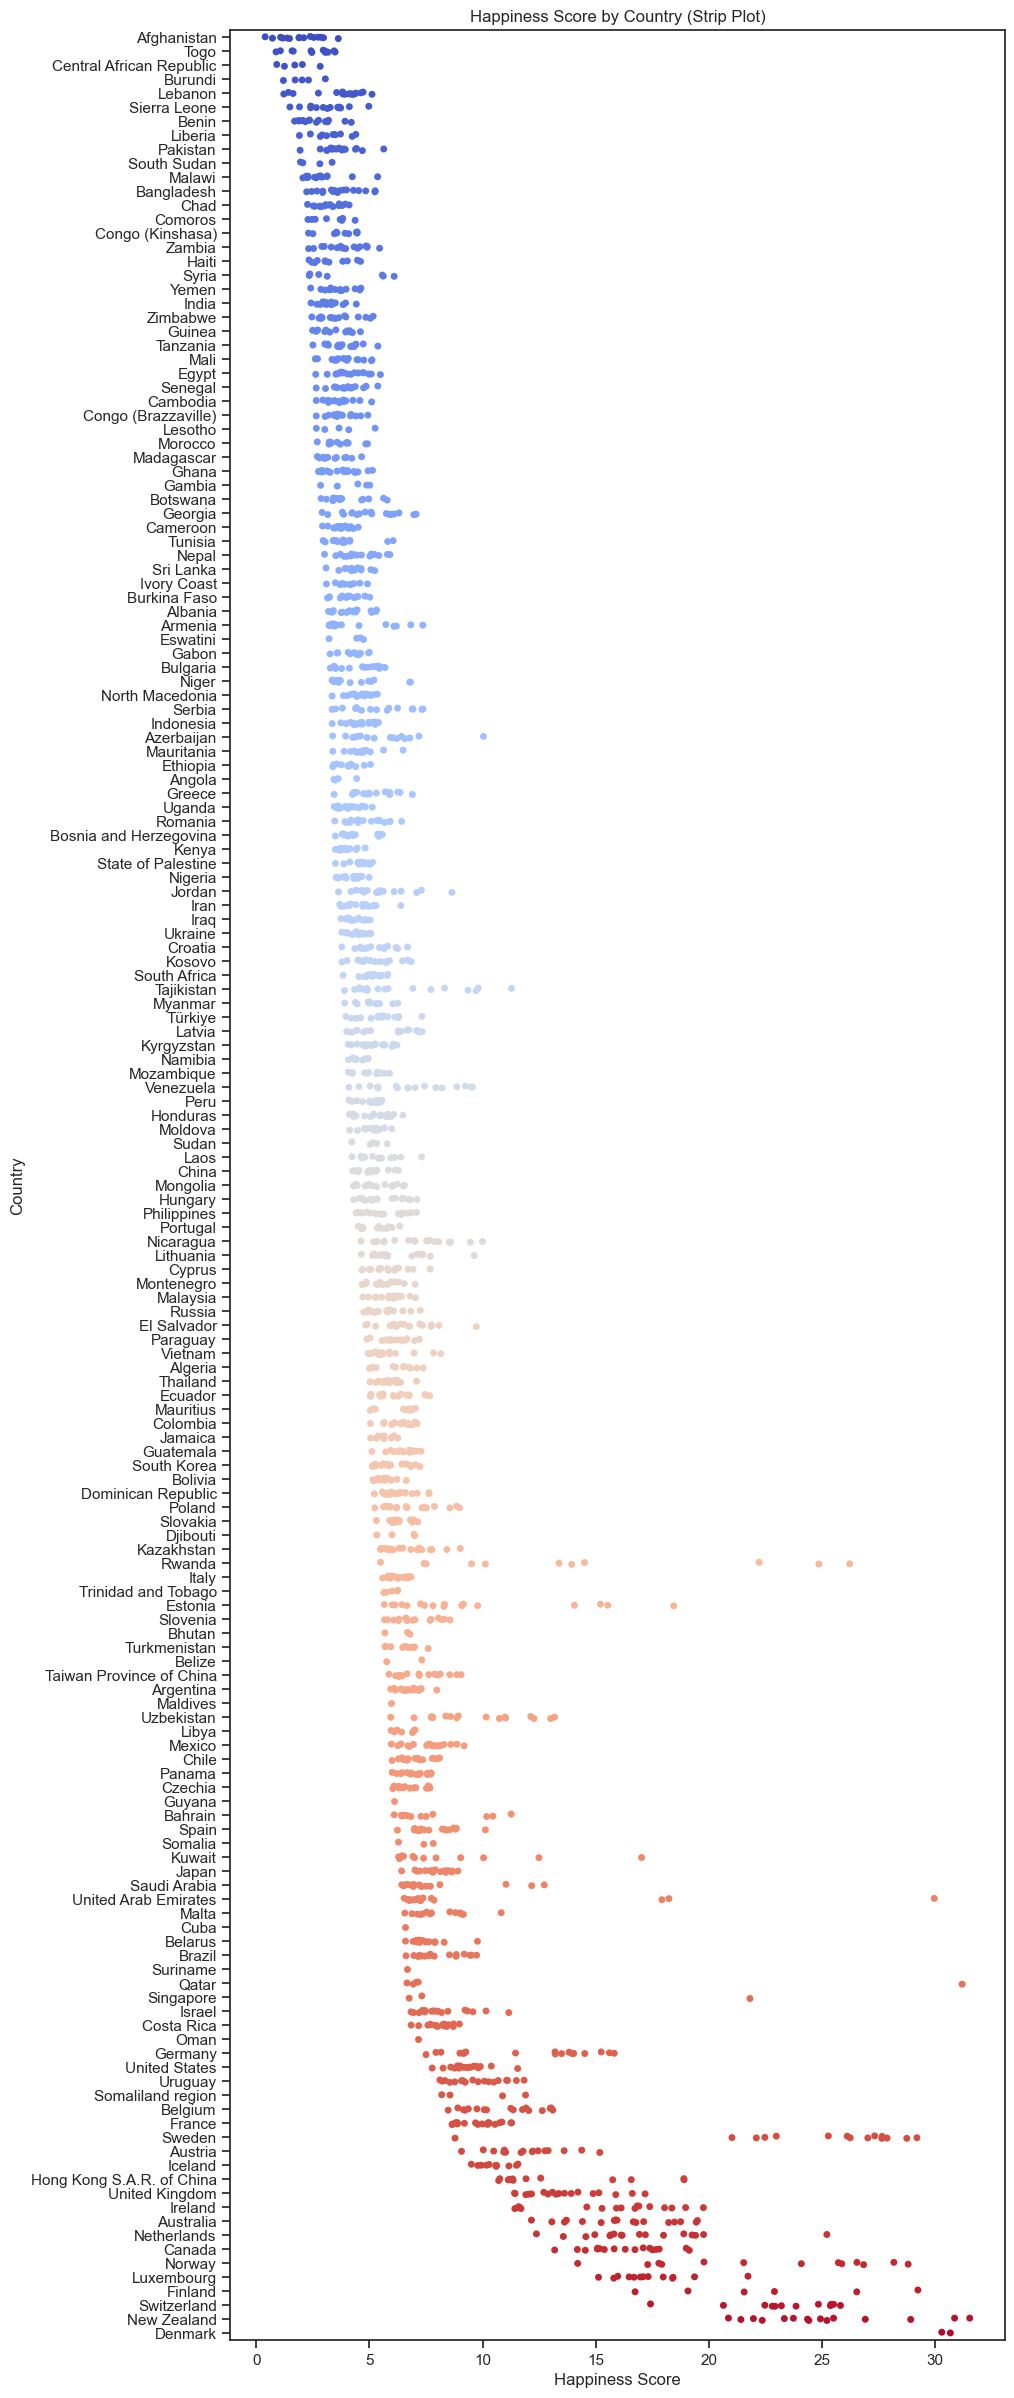

Strip plot saved successfully at: C:\Users\rbhte\OneDrive\monami\data_immersion\Achievement 6\Visualisations\Happiness_scores_strip_plot.png


In [18]:
# Create figure
plt.figure(figsize=(10, 30))

# Create strip plot with hue
sns.stripplot(
    x="Happiness Score", 
    y="Country name", 
    data=df_happy_sorted_1, 
    hue="Country name",  # Assign hue
    jitter=True,  # Prevent overlap
    size=5,  # Adjust point size
    palette="coolwarm",  # Use color mapping
    legend=False  # Hide legend to avoid clutter
)

# Labels and title
plt.xlabel("Happiness Score")
plt.ylabel("Country")
plt.title("Happiness Score by Country (Strip Plot)")

# Define the path
stripplot_path = os.path.join(path, 'Visualisations', 'Happiness_scores_strip_plot.png')

# Save the figure
plt.savefig(stripplot_path, bbox_inches="tight")
plt.show()

print(f"Strip plot saved successfully at: {stripplot_path}")

A strip plot helps visualize the distribution of Happiness Scores across countries. If Denmark, Sweden, New Zealand, Switzerland, Finland, Norway and Luxembourg are ranked as the happiest countries, we must question whether Happiness Score alone is enough to declare them the "happiest countries in the world."

Happiness is More Than Just a Score
    While Denmark, Sweden, New Zealand, Switzerland, Finland, Norway and Luxembourg rank high in happiness indices, they also struggle with serious social and mental health issues.
    A strip plot of Happiness Scores alone may be misleading, as it doesn't show depression rates, social isolation, birth rates, or overall life satisfaction.
    To truly determine the "happiest country," we need a more holistic approach that includes mental health, social bonds, and long-term optimism about life.

#  Questions that can be answered based on the explorations conducted so far

How do economic indicators like GDP, income inequality, and unemployment rates affect happiness and time use across nations?
Partially answerable – The heatmap shows correlations between log GDP per capita and happiness score, but income inequality and unemployment rates are not explicitly included.

In what ways do social systems such as healthcare and education influence time use and happiness?
Partially answerable – The correlation heatmap shows the relationship between healthy life expectancy at birth and happiness score, providing insights into healthcare's impact.

# **Formulating Hypotheses for Future Testing**

Freedom and Happiness

H₀: Perceived freedom to make life choices does not affect happiness scores.
H₁: Countries with higher freedom scores tend to have higher happiness scores.

# Saving the dataset 

In [19]:
# Define the export path
export_path = os.path.join(path, 'Data', 'Prepared Data', 'df_happy_tested.pkl')

# Save the cleaned dataframe as a pickle file
df_happy_copy.to_pickle(export_path)

print("File saved successfully at :", export_path)

File saved successfully at : C:\Users\rbhte\OneDrive\monami\data_immersion\Achievement 6\Data\Prepared Data\df_happy_tested.pkl
